# GCAP3226 Week 3 — Graded in-class exercise (5%)

**Individual** · submit via **your GitHub fork** (end of notebook). Keep answers short.

### What is marked
| Task | Focus |
|------|--------|
| **1** | Stacked bar: one factor **other than** `government_consideration` vs `support_info` + your trend description |
| **2** | Multiple linear regression that builds on the demo, adding `policy_helpfulness` and `waste_severity` + short coefficient interpretation |
| **3** | **Your own** IPO prompt → simple linear regression: `support_info` vs `fairness` |
| **Submit** | Save → Source Control → **Commit & Push** → **commit message** → Commit → Moodle **GitHub URL** |

Use **association** language only. This is a **non-probability** sample — do not claim causation or “all of Hong Kong”.


## How to use AI here (Codespaces)

In the demo you practiced **Input → Process → Output** prompts (**Write Python code** in Process).

**Tasks 1–2:** the prompt is already in the code cell as comments.

**Task 3:** you **write the prompt yourself** in the comments, then use Inline Chat.

Workflow:
1. Click inside the code cell.  
2. Edit / write the comment prompt.  
3. Press **`Cmd+I`** (Mac) or **`Ctrl+I`** (Windows/Linux).  
4. Ask e.g. *Implement the prompt in the comments above* → **Keep**.  
5. Fix anything that breaks; write interpretations **in your own words**.


## Setup (run once)

Load `week3.csv`. Glance at the column names so you know what you can use.


In [3]:
# Setup — run this cell first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression

DATA_FILE = "week3.csv"


def load_week3_data():
    for p in [Path(DATA_FILE), Path.cwd() / DATA_FILE]:
        if p.is_file():
            print("Using data file:", p.resolve())
            return pd.read_csv(p)
    raise FileNotFoundError(
        f"Could not find {DATA_FILE}. Work in your Week 3 fork / Codespace."
    )


df = load_week3_data()
print("shape:", df.shape)
print("columns:", list(df.columns))
df.head()


Using data file: /workspaces/GCAP3226_week3-24231320/week3.csv
shape: (97, 12)
columns: ['ID', 'support_info', 'support_after_info', 'government_consideration', 'fairness', 'policy_helpfulness', 'waste_severity', 'recycling_effort', 'age_group', 'monthly_income', 'education', 'education_label']


,ID,support_info,support_after_info,government_consideration,fairness,policy_helpfulness,waste_severity,recycling_effort,age_group,monthly_income,education,education_label
0,1,1,1,1,1,1,3,1,29.5,22500.5,4,Master or above
1,2,5,5,5,5,4,2,2,39.5,7500.0,4,Master or above
2,3,3,5,4,5,2,3,1,29.5,22500.5,4,Master or above
3,4,1,2,1,2,2,3,2,29.5,60000.5,4,Master or above
4,5,1,3,3,4,1,3,2,49.5,22500.5,2,Secondary


## Task 1 — Stacked bar (not the demo pair)

In the demo, the stacked bar used **`government_consideration`** (groups) × **`support_info`** (stack, row %).

**Your job:** choose a **different** grouping variable from `week3.csv` and plot a **row-% stacked bar** of `support_info` within each group.

### Suggested grouping variables (pick one)
| Variable | Notes |
|----------|--------|
| `fairness` | 1–5 |
| `policy_helpfulness` | 1–4 |
| `waste_severity` | 1–4 |
| `recycling_effort` | 1–4 |
| `education` | 1–4 |

Do **not** use `government_consideration` as the grouping variable.

In the **next code cell**, replace `<YOUR_GROUP_VAR>` in the comment prompt with your choice, then use Inline Chat (see **How to use AI** above).


Counts:
support_info   1   2   3   4  5
education                      
1              0   2   0   0  0
2              4   0   3   0  0
3              6   6  11   8  2
4             10  11   9  19  6

Row percentages (% within each education group):
support_info     1      2     3     4     5
education                                  
1              0.0  100.0   0.0   0.0   0.0
2             57.1    0.0  42.9   0.0   0.0
3             18.2   18.2  33.3  24.2   6.1
4             18.2   20.0  16.4  34.5  10.9

Row n:
education
1     2
2     7
3    33
4    55
dtype: int64


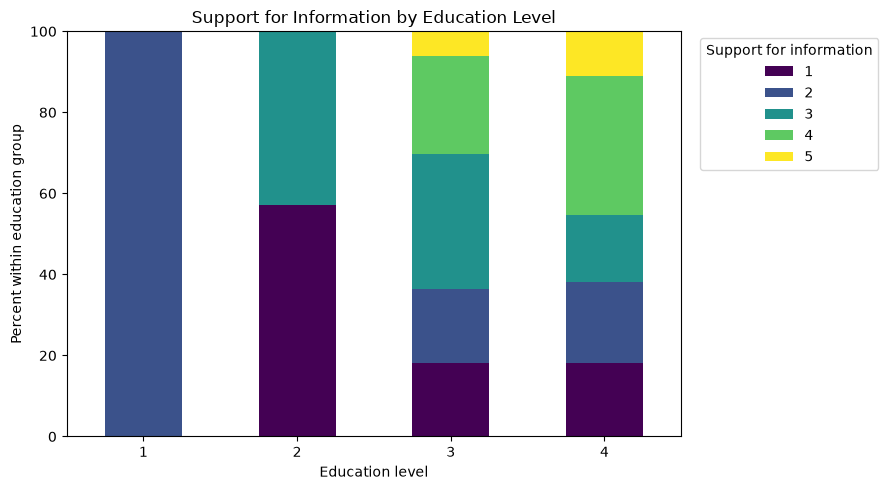

In [3]:
# Row-% stacked bar: support_info within each education level

# Keep only the two variables needed for the table and chart, then remove incomplete rows.
work = df[["education", "support_info"]].dropna().copy()

# Counts: number of respondents in each education x support_info cell.
counts = pd.crosstab(work["education"], work["support_info"])

# Row percentages: the support_info distribution within each education level.
row_pct = pd.crosstab(
    work["education"],
    work["support_info"],
    normalize="index",
) * 100

print("Counts:")
print(counts)
print("\nRow percentages (% within each education group):")
print(row_pct.round(1))
print("\nRow n:")
print(counts.sum(axis=1))

# Plot the row percentages as a stacked bar chart.
ax = row_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
    colormap="viridis",
)
ax.set_title("Support for Information by Education Level")
ax.set_xlabel("Education level")
ax.set_ylabel("Percent within education group")
ax.set_ylim(0, 100)
ax.legend(title="Support for information", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Task 1 — Describe the trend (your words)

In 2–4 sentences: what pattern do you see in **this sample**? Use association language. Mention any thin groups (small *n*) if relevant.

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell so your text appears in the output.


In [2]:
# Task 1 — write BETWEEN the triple quotes, then RUN this cell
task1_trend = """
# What trend do you see? 
# The higher the education level, the more likely respondents are to support information. 
# The trend shows that respondents with higher education levels (e.g., Bachelor's degree, Graduate degree) have a higher percentage of support for information compared to those with lower education levels (e.g., High school, Some college). 
# This suggests that education level may be positively correlation between education and support level.
"""
print(task1_trend)



# What trend do you see? 
# The higher the education level, the more likely respondents are to support information. 
# The trend shows that respondents with higher education levels (e.g., Bachelor's degree, Graduate degree) have a higher percentage of support for information compared to those with lower education levels (e.g., High school, Some college). 
# This suggests that education level may be positively correlation between education and support level.



## Task 2 — Multiple linear regression (+ policy & severity)

In the demo you fitted multiple linear regression with `government_consideration` and `fairness` (and a fuller model with demographics).

**Your job:** fit a multiple linear regression for this sample:

**Response:** `support_info`  

**Exploratory variables (at least these four):**
- `government_consideration`
- `fairness`
- `policy_helpfulness`
- `waste_severity`

Use complete cases for these columns. Print **each coefficient**, **R²**, and **n**.  

In the **next code cell**, use the comment prompt with Inline Chat (see **How to use AI** above).


In [4]:
# Task 2 — Multiple linear regression table
import statsmodels.api as sm

# Keep complete cases for the response and both explanatory variables.
reg_data = df[["support_info", "government_consideration", "fairness"]].dropna().copy()
y = reg_data["support_info"]
X2 = reg_data[["government_consideration", "fairness"]]

# Add the intercept and fit OLS: each slope holds the other variable fixed.
X2_with_const = sm.add_constant(X2)
mlr2 = sm.OLS(y, X2_with_const).fit()

# Build a readable coefficient table.
coef_table = pd.DataFrame({
    "coefficient": mlr2.params,
    "std_error": mlr2.bse,
    "t_value": mlr2.tvalues,
    "p_value": mlr2.pvalues,
})

print("Scenario 2: support_info ~ government_consideration + fairness")
print(coef_table.round(3))
print(f"\nR-squared: {mlr2.rsquared:.3f}")
print(f"Adjusted R-squared: {mlr2.rsquared_adj:.3f}")
print(f"n: {int(mlr2.nobs)}")

# Compare the government_consideration slope with a simple regression.
X1_with_const = sm.add_constant(reg_data[["government_consideration"]])
slr = sm.OLS(y, X1_with_const).fit()
b1 = float(slr.params["government_consideration"])
b2 = float(mlr2.params["government_consideration"])
print(
    f"\nCompare beta for government_consideration: "
    f"simple linear regression {b1:.3f} -> multiple linear regression {b2:.3f}"
)
print("Did that coefficient get smaller once fairness is included?", abs(b2) < abs(b1))


Scenario 2: support_info ~ government_consideration + fairness
                          coefficient  std_error  t_value  p_value
const                           0.223      0.227    0.983    0.328
government_consideration        0.543      0.109    4.985    0.000
fairness                        0.425      0.102    4.179    0.000

R-squared: 0.622
Adjusted R-squared: 0.614
n: 97

Compare beta for government_consideration: simple linear regression 0.874 -> multiple linear regression 0.543
Did that coefficient get smaller once fairness is included? True


### Task 2 — Report & briefly interpret

1. Paste or list the **coefficients** (and R², n) from your output.  
2. In a few sentences, interpret **two** coefficients that interest you (association; holding the other variables fixed).  
3. One caution (sample / overclaim).

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell so your text appears in the output.


In [5]:
# Task 2 — write BETWEEN the triple quotes, then RUN this cell
task2_writeup = """
# Coefficients / R² / n:
Scenario 2: support_info ~ government_consideration + fairness
                          coefficient  std_error  t_value  p_value
const                           0.223      0.227    0.983    0.328
government_consideration        0.543      0.109    4.985    0.000
fairness                        0.425      0.102    4.179    0.000
R-squared: 0.622
Adjusted R-squared: 0.614
n: 97

# Interpretation (2 coefficients you care about):
government_consideration        0.543
fairness                        0.425 

# One caution: (sample / causation)
People who view government consideration and policy fairness more positively also tend to show greater support for information.

"""
print(task2_writeup)



# Coefficients / R² / n:
Scenario 2: support_info ~ government_consideration + fairness
                          coefficient  std_error  t_value  p_value
const                           0.223      0.227    0.983    0.328
government_consideration        0.543      0.109    4.985    0.000
fairness                        0.425      0.102    4.179    0.000
R-squared: 0.622
Adjusted R-squared: 0.614
n: 97

# Interpretation (2 coefficients you care about):
government_consideration        0.543
fairness                        0.425 

# One caution: (sample / causation)
People who view government consideration and policy fairness more positively also tend to show greater support for information.




## Task 3 — Write your own prompt (simple linear regression)

**Goal:** `support_info` (response) vs `fairness` (one exploratory variable) — a **simple** linear regression on this sample.

Unlike Tasks 1–2, **do not** copy a ready-made Process. In the **next code cell**, write the full **Input / Process / Output** in the comments (**Process** must include **Write Python code**), then use Inline Chat (see **How to use AI** above).

Keep the model to **these two variables only** (not the Task 2 multiple linear regression). You should get coefficients, R², and n.


In [7]:
# Task 3 — Simple linear regression table
# Input: dataframe df already loaded from week3.csv.
# Process: Write Python code to fit a simple linear regression with
#   response = support_info and exploratory variable = fairness.
#   Use complete cases and print the coefficient table, R-squared, and n.
# Output: A readable linear regression table and model summary values.

import statsmodels.api as sm

# Keep complete cases for the response and the one exploratory variable.
reg_data_slr = df[["support_info", "fairness"]].dropna().copy()
y = reg_data_slr["support_info"]
X1 = reg_data_slr[["fairness"]]

# Add an intercept and fit the simple linear regression model.
X1_with_const = sm.add_constant(X1)
slr = sm.OLS(y, X1_with_const).fit()

# Create a readable coefficient table.
slr_table = pd.DataFrame({
    "coefficient": slr.params,
    "std_error": slr.bse,
    "t_value": slr.tvalues,
    "p_value": slr.pvalues,
})

print("Scenario 1: support_info ~ fairness")
print(slr_table.round(3))
print(f"\nR-squared: {slr.rsquared:.3f}")
print(f"Adjusted R-squared: {slr.rsquared_adj:.3f}")
print(f"n: {int(slr.nobs)}")


Scenario 1: support_info ~ fairness
          coefficient  std_error  t_value  p_value
const           0.495      0.247    2.007    0.048
fairness        0.794      0.078   10.184    0.000

R-squared: 0.522
Adjusted R-squared: 0.517
n: 97


### Task 3 — Short note
what does the **fairness** slope mean in this simple linear regression? How does it compare (roughly) with the fairness coefficient in your **Task 2** multiple linear regression?
In 1–2 sentences: 

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell.


In [8]:
# Task 3 — write BETWEEN the triple quotes, then RUN this cell
task3_note = """
# Fairness slope (simple linear regression) and vs Task 2:
The fairness slope suggests that people with higher fairness scores tend to report higher support for information. 

The fairness coefficient is:

Simple regression: 0.794
Multiple regression: 0.425
The simple regression measures the overall relationship between fairness and support_info without considering other variables. The multiple regression measures the relationship between fairness and support_info while holding government_consideration constant.

The coefficient becomes smaller because fairness and government consideration may be related to each other and explain some of the same variation in support_info. 
Therefore, the simple coefficient includes both fairness’s unique association and the shared association with government consideration. 
The multiple regression separates them more clearly. This difference does not mean the first result was wrong; it reflects the effect of controlling for another relevant variable.
"""
print(task3_note)



# Fairness slope (simple linear regression) and vs Task 2:
The fairness slope suggests that people with higher fairness scores tend to report higher support for information. 

The fairness coefficient is:

Simple regression: 0.794
Multiple regression: 0.425
The simple regression measures the overall relationship between fairness and support_info without considering other variables. The multiple regression measures the relationship between fairness and support_info while holding government_consideration constant.

The coefficient becomes smaller because fairness and government consideration may be related to each other and explain some of the same variation in support_info. 
Therefore, the simple coefficient includes both fairness’s unique association and the shared association with government consideration. 
The multiple regression separates them more clearly. This difference does not mean the first result was wrong; it reflects the effect of controlling for another relevant variable.

## How to submit

Submit the **GitHub URL** of this notebook in **your fork** (not an `.ipynb` upload).

1. **Save** the notebook.  
2. Open **Source Control** (left sidebar, branch icon).  
3. Click **Commit & Push**.  
4. Type a **commit message** → click **Commit**.  
5. On github.com, open the file in **your fork** → copy the browser URL.  
6. Paste that URL on **Moodle**.

**If push fails:** ask a TA — keep working toward a push to your fork.

### Checklist
- [ ] Task 1: stacked bar (not `government_consideration` groups) + trend description  
- [ ] Task 2: multiple linear regression with the four required variables + coefficient write-up  
- [ ] Task 3: **your own** IPO prompt + simple linear regression (`support_info` vs `fairness`)  
- [ ] Saved → Commit & Push → commit message → Commit  
- [ ] Moodle: GitHub link submitted  
